---

## <center> 기본 세팅

---

In [1]:
import os
import sys
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import scipy as sp

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:
    
    plt.rc('font', family='NanumGothic')

# 마이너스 기호방지
plt.rcParams['axes.unicode_minus'] = False

---

## <center> 파일 불러오기

---

In [3]:
# 데이터 경로 설정
aisles_path = '../데이터 폴더\Instamart_dataset/aisles.csv'
departments_path = '../데이터 폴더\Instamart_dataset/departments.csv'
products_path = '../데이터 폴더\Instamart_dataset/products.csv'
orders_path = '../데이터 폴더\Instamart_dataset/orders.csv'
order_products__prior_path = '../데이터 폴더\Instamart_dataset/order_products__prior.csv'
order_products__train_path = '../데이터 폴더\Instamart_dataset/order_products__train.csv'


In [4]:
# 데이터 불러오기
df1 = pd.read_csv(products_path)
df2 = pd.read_csv(aisles_path)
df3 = pd.read_csv(departments_path)
df4 = pd.read_csv(order_products__train_path)
df5 = pd.read_csv(orders_path)
print(df5.head())

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  


In [5]:
## 데이터 프레임 결합
# aisles + products
df12 = pd.merge(df2, df1, how='inner', on='aisle_id')
print(f' 1 ')
# aisles_products + departments
df123 = pd.merge(df12, df3, how='inner', on='department_id')
print(f' 2 ')
# aisles_products_departments + orders
df1234 = pd.merge(df4, df123, how='inner', on='product_id')
print(f' 3 ')
# aisles_products_departments_orders + order_products__prior
df12345 = pd.merge(df5, df1234, how='inner', on='order_id')
print(f' 4 ')
df =df12345.drop(['aisle_id', 'department_id', 'order_number'], axis=1)
display(df.head())
print('\n\033[1mInference:\033[0m The Datset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

 1 
 2 
 3 
 4 


,order_id,user_id,eval_set,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle,product_name,department
0,1187899,1,train,4,8,14.0,196,1,1,soft drinks,Soda,beverages
1,1187899,1,train,4,8,14.0,25133,2,1,packaged cheese,Organic String Cheese,dairy eggs
2,1187899,1,train,4,8,14.0,38928,3,1,yogurt,0% Greek Strained Yogurt,dairy eggs
3,1187899,1,train,4,8,14.0,26405,4,1,paper goods,XL Pick-A-Size Paper Towel Rolls,household
4,1187899,1,train,4,8,14.0,39657,5,1,candy chocolate,Milk Chocolate Almonds,snacks



Inference: The Datset consists of 12 features & 1384617 samples.


In [6]:
# 모든 컬럼 dytype 확인
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1384617 non-null  int64  
 1   user_id                 1384617 non-null  int64  
 2   eval_set                1384617 non-null  str    
 3   order_dow               1384617 non-null  int64  
 4   order_hour_of_day       1384617 non-null  int64  
 5   days_since_prior_order  1384617 non-null  float64
 6   product_id              1384617 non-null  int64  
 7   add_to_cart_order       1384617 non-null  int64  
 8   reordered               1384617 non-null  int64  
 9   aisle                   1384617 non-null  str    
 10  product_name            1384617 non-null  str    
 11  department              1384617 non-null  str    
dtypes: float64(1), int64(7), str(4)
memory usage: 126.8 MB
None


In [7]:
# 고유 컬럼 값 확인
for col in df.columns:
    print(f'Column: {col} | Unique Values: {df[col].nunique()}')

Column: order_id | Unique Values: 131209
Column: user_id | Unique Values: 131209
Column: eval_set | Unique Values: 1
Column: order_dow | Unique Values: 7
Column: order_hour_of_day | Unique Values: 24
Column: days_since_prior_order | Unique Values: 31
Column: product_id | Unique Values: 39123
Column: add_to_cart_order | Unique Values: 80
Column: reordered | Unique Values: 2
Column: aisle | Unique Values: 134
Column: product_name | Unique Values: 39123
Column: department | Unique Values: 21


In [8]:
# 고유 행 값 확인
print(df.nunique().sort_values(ascending=False))

order_id                  131209
user_id                   131209
product_name               39123
product_id                 39123
aisle                        134
add_to_cart_order             80
days_since_prior_order        31
order_hour_of_day             24
department                    21
order_dow                      7
reordered                      2
eval_set                       1
dtype: int64


In [9]:
# 모든 컬럼 기초통계 확인
display(df.describe())

,order_id,user_id,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
count,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06
mean,1.706298e+06,1.031128e+05,2.701392e+00,1.357759e+01,1.706613e+01,2.555624e+04,8.758044e+00,5.985944e-01
std,9.897326e+05,5.948715e+04,2.167646e+00,4.238458e+00,1.042642e+01,1.412127e+04,7.423936e+00,4.901829e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.433700e+05,5.173200e+04,1.000000e+00,1.000000e+01,7.000000e+00,1.338000e+04,3.000000e+00,0.000000e+00
50%,1.701880e+06,1.029330e+05,3.000000e+00,1.400000e+01,1.500000e+01,2.529800e+04,7.000000e+00,1.000000e+00
75%,2.568023e+06,1.549590e+05,5.000000e+00,1.700000e+01,3.000000e+01,3.794000e+04,1.200000e+01,1.000000e+00
max,3.421070e+06,2.062090e+05,6.000000e+00,2.300000e+01,3.000000e+01,4.968800e+04,8.000000e+01,1.000000e+00


---

## <center> 1. 데이터 탐색

---

주문당 평균 구매 상품 수: 10.55


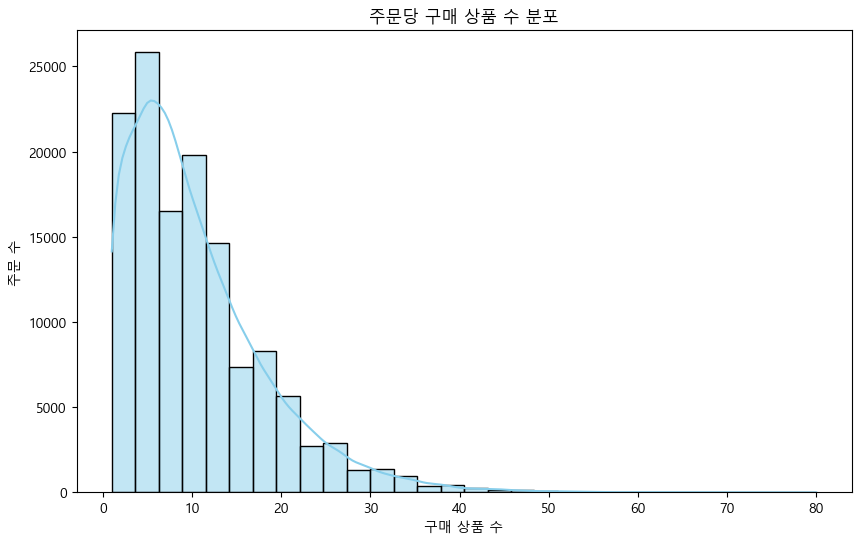

In [10]:
# 첫번째 분석: 주문당 평균 구매 상품 수 분석
order_product_counts = df.groupby('order_id')['product_id'].count()
average_products_per_order = order_product_counts.mean()
print(f'주문당 평균 구매 상품 수: {average_products_per_order:.2f}')
# 시각화
plt.figure(figsize=(10, 6))
sns.histplot(order_product_counts, bins=30, kde=True, color='skyblue')
plt.title('주문당 구매 상품 수 분포')
plt.xlabel('구매 상품 수')
plt.ylabel('주문 수')
plt.show()

가장 인기 있는 상품 카테고리 상위 10개:


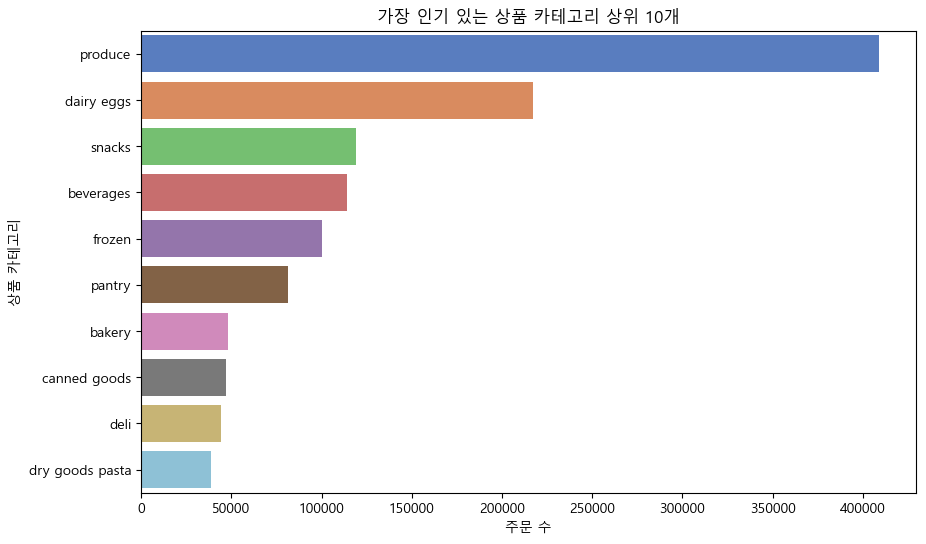

In [11]:
# 두번째 분석: 가장 인기 있는 상품 카테고리 분석
popular_departments = df['department'].value_counts().head(10)
print('가장 인기 있는 상품 카테고리 상위 10개:')
# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=popular_departments.values, y=popular_departments.index, palette='muted')
plt.title('가장 인기 있는 상품 카테고리 상위 10개')
plt.xlabel('주문 수')
plt.ylabel('상품 카테고리')
plt.show()


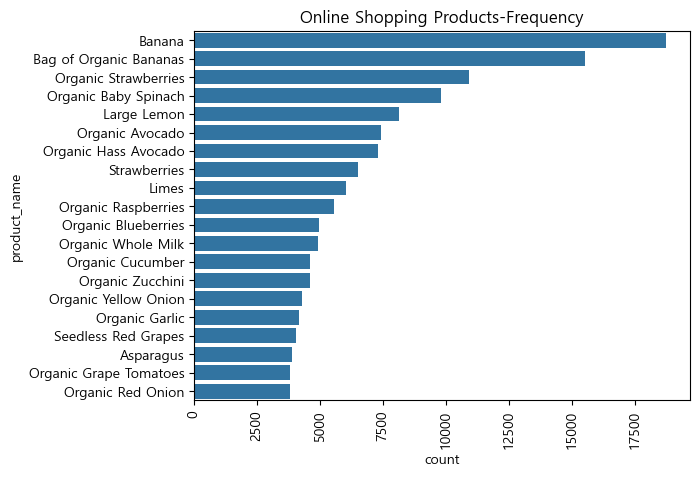

In [12]:
# 세번째 분석: 가장 자주 구매되는 상품 분석
sns.countplot(df.product_name, order=df.product_name.value_counts().index[:20])
plt.title('Online Shopping Products-Frequency')
plt.xticks(rotation=90)
plt.show()

Text(0.5, 0, '시간대 (0-23시)')

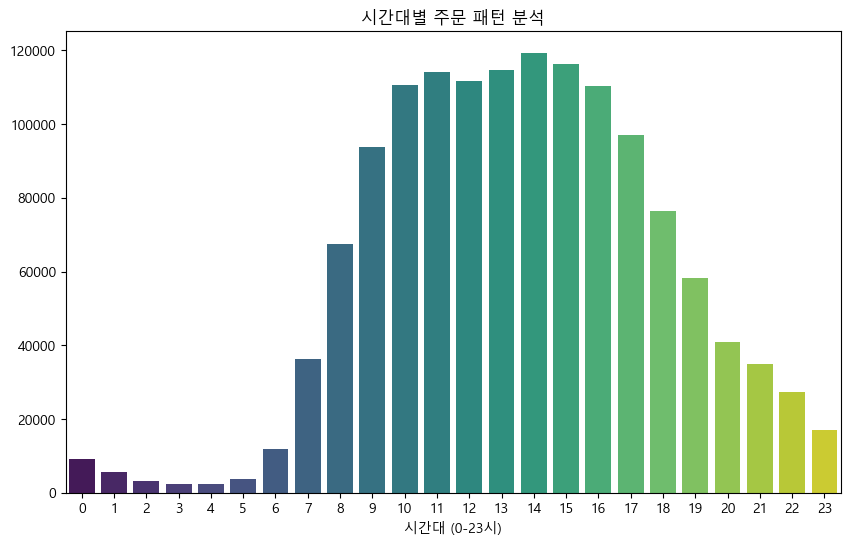

In [13]:
# 네번쨰 분석: 특정 시간대의 주문 패턴 분석
df['order_hour_of_day'] = df['order_hour_of_day'].astype(int)
hourly_orders = df['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_orders.index, y=hourly_orders.values, palette='viridis')
plt.title('시간대별 주문 패턴 분석')
plt.xlabel('시간대 (0-23시)')

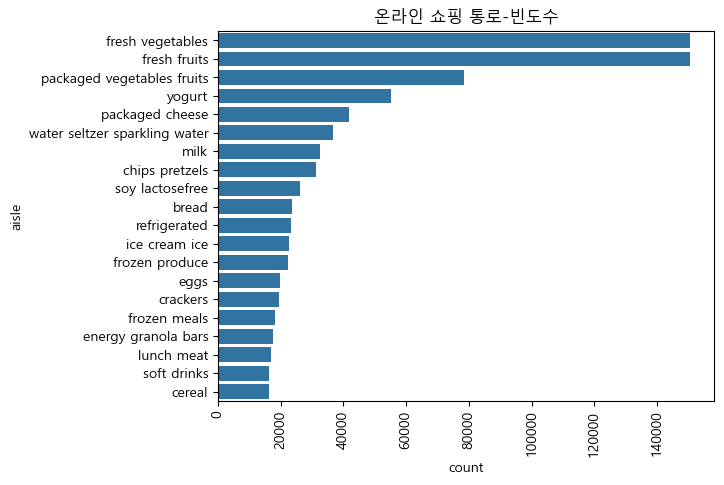

In [14]:
# 다섯번째 온라인 쇼핑 통로-빈도수 확인
sns.countplot(df.aisle, order=df.aisle.value_counts().index[:20])
plt.title('온라인 쇼핑 통로-빈도수')
plt.xticks(rotation=90)
plt.show()

---

### <center> 2. 데이터 전처리

---

In [ ]:
# 결측치 확인
print(df.isnull().sum())

order_id                  0
user_id                   0
eval_set                  0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
aisle                     0
product_name              0
department                0
dtype: int64


In [ ]:
# 중복된 행이 있다면 제거 (만약에)

counter = 0
r,c = df.shape

df1 = df.drop_duplicates()
df1.reset_index(drop=True, inplace=True)

if df1.shape[0] != r:
    counter += 1
    print(f'중복된 행이 {r - df1.shape[0]}개 제거되었습니다.')
    df = df1.copy()
else:
    print('중복된 행이 없습니다.')
if counter == 0:
    print('데이터 클린징이 완료되었습니다.')

중복된 행이 없습니다.
데이터 클린징이 완료되었습니다.


In [ ]:
# 범주형 변수를 더미 변수로 변환
dummies_df = pd.get_dummies(data=df, prefix=['Day','Hour'], columns=['order_dow','order_hour_of_day'], drop_first=True)
dummies_df.head()

,order_id,user_id,eval_set,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle,product_name,department,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,1187899,1,train,14.0,196,1,1,soft drinks,Soda,beverages,...,False,False,False,False,False,False,False,False,False,False
1,1187899,1,train,14.0,25133,2,1,packaged cheese,Organic String Cheese,dairy eggs,...,False,False,False,False,False,False,False,False,False,False
2,1187899,1,train,14.0,38928,3,1,yogurt,0% Greek Strained Yogurt,dairy eggs,...,False,False,False,False,False,False,False,False,False,False
3,1187899,1,train,14.0,26405,4,1,paper goods,XL Pick-A-Size Paper Towel Rolls,household,...,False,False,False,False,False,False,False,False,False,False
4,1187899,1,train,14.0,39657,5,1,candy chocolate,Milk Chocolate Almonds,snacks,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# user_id와 product_id별로 집계
user_prod_df = dummies_df.groupby(['user_id','product_id']).agg({'order_id':'nunique',
                                                                 'days_since_prior_order':'mean',
                                                                 'reordered':'max',
                                                                 'Day_1':'sum',
                                                                 'Day_2':'sum',
                                                                 'Day_3':'sum',
                                                                 'Day_4':'sum',
                                                                 'Day_5':'sum',
                                                                 'Day_6':'sum',
                                                                 'Hour_1':'sum',
                                                                 'Hour_2':'sum',
                                                                 'Hour_3':'sum',
                                                                 'Hour_4':'sum',
                                                                 'Hour_5':'sum',
                                                                 'Hour_6':'sum',
                                                                 'Hour_7':'sum',
                                                                 'Hour_8':'sum',
                                                                 'Hour_9':'sum',
                                                                 'Hour_10':'sum',
                                                                 'Hour_11':'sum',
                                                                 'Hour_12':'sum',
                                                                 'Hour_13':'sum',
                                                                 'Hour_14':'sum',
                                                                 'Hour_15':'sum',
                                                                 'Hour_16':'sum',
                                                                 'Hour_17':'sum',
                                                                 'Hour_18':'sum',
                                                                 'Hour_19':'sum',
                                                                 'Hour_20':'sum',
                                                                 'Hour_21':'sum',
                                                                 'Hour_22':'sum',
                                                                 'Hour_23':'sum'
                                                                }).reset_index()
user_prod_df.head()

,user_id,product_id,order_id,days_since_prior_order,reordered,Day_1,Day_2,Day_3,Day_4,Day_5,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,1,196,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,10258,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,13032,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,25133,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1,26088,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# user_id별로 집계
user_purchase_df = dummies_df.groupby(['user_id']).agg({         'order_id':'nunique',
                                                                 'product_id': 'nunique',
                                                                 'days_since_prior_order':'mean',
                                                                 'reordered':'sum',
                                                                 'Day_1':'sum',
                                                                 'Day_2':'sum',
                                                                 'Day_3':'sum',
                                                                 'Day_4':'sum',
                                                                 'Day_5':'sum',
                                                                 'Day_6':'sum',
                                                                 'Hour_1':'sum',
                                                                 'Hour_2':'sum',
                                                                 'Hour_3':'sum',
                                                                 'Hour_4':'sum',
                                                                 'Hour_5':'sum',
                                                                 'Hour_6':'sum',
                                                                 'Hour_7':'sum',
                                                                 'Hour_8':'sum',
                                                                 'Hour_9':'sum',
                                                                 'Hour_10':'sum',
                                                                 'Hour_11':'sum',
                                                                 'Hour_12':'sum',
                                                                 'Hour_13':'sum',
                                                                 'Hour_14':'sum',
                                                                 'Hour_15':'sum',
                                                                 'Hour_16':'sum',
                                                                 'Hour_17':'sum',
                                                                 'Hour_18':'sum',
                                                                 'Hour_19':'sum',
                                                                 'Hour_20':'sum',
                                                                 'Hour_21':'sum',
                                                                 'Hour_22':'sum',
                                                                 'Hour_23':'sum'
                                                                }).reset_index()
user_purchase_df.head()

,user_id,order_id,product_id,days_since_prior_order,reordered,Day_1,Day_2,Day_3,Day_4,Day_5,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,1,1,11,14.0,10,0,0,0,11,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,31,30.0,12,31,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,5,1,9,6.0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7,1,9,6.0,8,0,9,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,1,18,10.0,4,18,0,0,0,0,...,18,0,0,0,0,0,0,0,0,0


In [ ]:
# product_id별로 집계
product_purchase_df = dummies_df.groupby(['product_id']).agg({   'order_id':'nunique',
                                                                 'user_id': 'nunique',
                                                                 'days_since_prior_order':'mean',
                                                                 'reordered':'sum',
                                                                 'Day_1':'sum',
                                                                 'Day_2':'sum',
                                                                 'Day_3':'sum',
                                                                 'Day_4':'sum',
                                                                 'Day_5':'sum',
                                                                 'Day_6':'sum',
                                                                 'Hour_1':'sum',
                                                                 'Hour_2':'sum',
                                                                 'Hour_3':'sum',
                                                                 'Hour_4':'sum',
                                                                 'Hour_5':'sum',
                                                                 'Hour_6':'sum',
                                                                 'Hour_7':'sum',
                                                                 'Hour_8':'sum',
                                                                 'Hour_9':'sum',
                                                                 'Hour_10':'sum',
                                                                 'Hour_11':'sum',
                                                                 'Hour_12':'sum',
                                                                 'Hour_13':'sum',
                                                                 'Hour_14':'sum',
                                                                 'Hour_15':'sum',
                                                                 'Hour_16':'sum',
                                                                 'Hour_17':'sum',
                                                                 'Hour_18':'sum',
                                                                 'Hour_19':'sum',
                                                                 'Hour_20':'sum',
                                                                 'Hour_21':'sum',
                                                                 'Hour_22':'sum',
                                                                 'Hour_23':'sum'
                                                                }).reset_index()
product_purchase_df.head()

,product_id,order_id,user_id,days_since_prior_order,reordered,Day_1,Day_2,Day_3,Day_4,Day_5,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,1,76,76,17.118421,49,14,14,10,13,14,...,5,3,4,8,1,3,0,1,4,0
1,2,4,4,10.750000,1,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
2,3,6,6,21.000000,6,0,0,2,0,2,...,0,0,2,0,0,0,0,0,0,0
3,4,22,22,17.272727,14,2,5,3,1,1,...,3,2,3,2,3,2,0,0,0,1
4,5,1,1,21.000000,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# user_id와 product_id별로 집계한 데이터프레임과 user_id별로 집계한 데이터프레임을 병합
temp = pd.merge(left=user_prod_df, right=user_purchase_df, on='user_id', suffixes=('', '_user'))
temp.head(10)

,user_id,product_id,order_id,days_since_prior_order,reordered,Day_1,Day_2,Day_3,Day_4,Day_5,...,Hour_14_user,Hour_15_user,Hour_16_user,Hour_17_user,Hour_18_user,Hour_19_user,Hour_20_user,Hour_21_user,Hour_22_user,Hour_23_user
0,1,196,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,10258,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,13032,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,25133,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1,26088,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,1,26405,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,1,27845,1,14.0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,1,38928,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
8,1,39657,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,1,46149,1,14.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
# user_id와 product_id별로 집계한 데이터프레임과 product_id별로 집계한 데이터프레임을 병합
features_df = pd.merge(left=temp,  right=product_purchase_df, on='product_id', suffixes=('','_prod'))
features_df.head(10)

,user_id,product_id,order_id,days_since_prior_order,reordered,Day_1,Day_2,Day_3,Day_4,Day_5,...,Hour_14_prod,Hour_15_prod,Hour_16_prod,Hour_17_prod,Hour_18_prod,Hour_19_prod,Hour_20_prod,Hour_21_prod,Hour_22_prod,Hour_23_prod
0,1,196,1,14.0,1,0,0,0,1,0,...,135,124,78,79,56,42,25,34,22,16
1,1,10258,1,14.0,1,0,0,0,1,0,...,11,5,6,8,3,0,1,0,5,1
2,1,13032,1,14.0,1,0,0,0,1,0,...,14,11,6,9,6,4,6,2,7,2
3,1,25133,1,14.0,1,0,0,0,1,0,...,17,16,13,9,9,8,7,5,3,3
4,1,26088,1,14.0,1,0,0,0,1,0,...,15,7,10,7,4,3,3,6,4,4
5,1,26405,1,14.0,1,0,0,0,1,0,...,6,13,4,6,1,2,4,4,1,0
6,1,27845,1,14.0,0,0,0,0,1,0,...,436,400,349,325,249,213,161,133,104,66
7,1,38928,1,14.0,1,0,0,0,1,0,...,32,26,30,18,10,12,10,3,15,2
8,1,39657,1,14.0,1,0,0,0,1,0,...,26,15,23,8,6,3,6,1,7,1
9,1,46149,1,14.0,1,0,0,0,1,0,...,34,33,18,11,8,6,2,7,7,6


In [ ]:
# 사용자-상품 특징 데이터프레임 인덱스 재설정 함수
def my_reset(varnames):
    for var in varnames:
        globals()[var].reset_index(drop=True, inplace=True)


In [ ]:
def my_reset(varnames):
    """
    varnames are what you want to keep
    """
    globals_ = globals()
    to_save = {v: globals_[v] for v in varnames}
    to_save['my_reset'] = my_reset  # lets keep this function by default
    del globals_
    get_ipython().magic("reset")
    globals().update(to_save)
    
variables = ['features_df']
my_reset(variables)